In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(75,75,1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(7, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


C:\ProgramData\miniconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 73, 73, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 36, 36, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 34, 34, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 17, 17, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 15, 15, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 7, 7, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         802,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 7)                   │             903 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 896,519 (3.42 MB)

 Trainable params: 896,519 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)


Epoch 1/20
751/751 ━━━━━━━━━━━━━━━━━━━━ 715s 947ms/step - accuracy: 0.4309 - loss: 1.4881 - val_accuracy: 0.5781 - val_loss: 1.1535
Epoch 2/20
751/751 ━━━━━━━━━━━━━━━━━━━━ 96s 128ms/step - accuracy: 0.6126 - loss: 1.0672 - val_accuracy: 0.6603 - val_loss: 0.9407
Epoch 3/20
751/751 ━━━━━━━━━━━━━━━━━━━━ 96s 128ms/step - accuracy: 0.6799 - loss: 0.8848 - val_accuracy: 0.7186 - val_loss: 0.7817
Epoch 4/20
751/751 ━━━━━━━━━━━━━━━━━━━━ 93s 123ms/step - accuracy: 0.7285 - loss: 0.7479 - val_accuracy: 0.7563 - val_loss: 0.6773
Epoch 5/20
751/751 ━━━━━━━━━━━━━━━━━━━━ 96s 128ms/step - accuracy: 0.7680 - loss: 0.6409 - val_accuracy: 0.7741 - val_loss: 0.6454
Epoch 6/20
751/751 ━━━━━━━━━━━━━━━━━━━━ 91s 122ms/step - accuracy: 0.7925 - loss: 0.5600 - val_accuracy: 0.7855 - val_loss: 0.6241
Epoch 7/20
751/751 ━━━━━━━━━━━━━━━━━━━━ 84s 111ms/step - accuracy: 0.8190 - loss: 0.4950 - val_accuracy: 0.8033 - val_loss: 0.5695
Epoch 8/20
751/751 ━━━━━━━━━━━━━━━━━━━━ 92s 122ms/step - accuracy: 0.8350 - loss: 

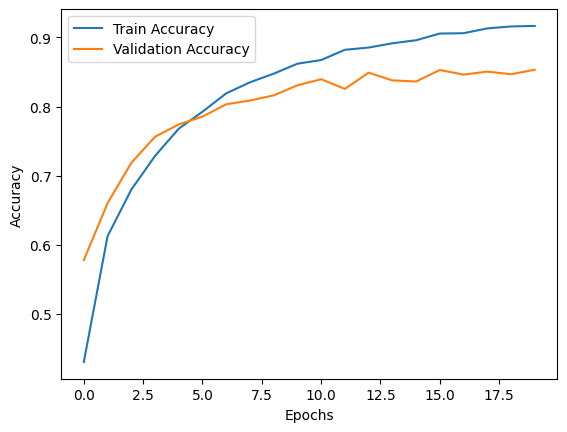

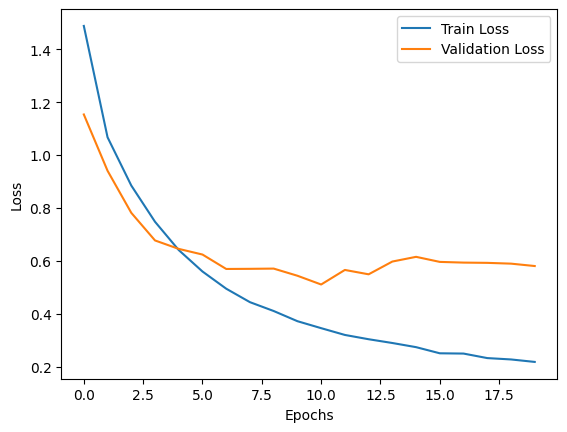

In [6]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [7]:
test_loss, test_accuracy = model.evaluate(test_data)
print("Test Accuracy:", test_accuracy)


131/131 ━━━━━━━━━━━━━━━━━━━━ 88s 678ms/step - accuracy: 0.8727 - loss: 0.4957 
Test Accuracy: 0.8727490901947021


131/131 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step


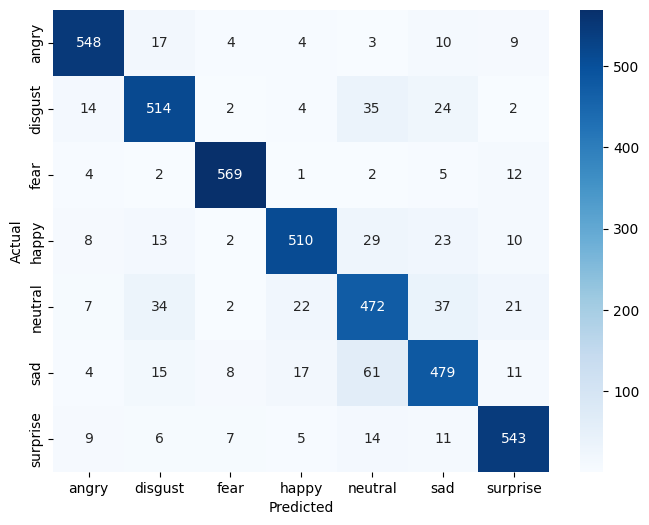

              precision    recall  f1-score   support

       angry       0.92      0.92      0.92       595
     disgust       0.86      0.86      0.86       595
        fear       0.96      0.96      0.96       595
       happy       0.91      0.86      0.88       595
     neutral       0.77      0.79      0.78       595
         sad       0.81      0.81      0.81       595
    surprise       0.89      0.91      0.90       595

    accuracy                           0.87      4165
   macro avg       0.87      0.87      0.87      4165
weighted avg       0.87      0.87      0.87      4165



In [8]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get predictions
y_pred = model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_data.classes
class_names = list(test_data.class_indices.keys())

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification report
print(classification_report(y_true, y_pred_classes, target_names=class_names))
